# Brasaland Sales Forecast — Model Evaluation (Context-20)

Formal **diagnosis** of the context-19 Random Forest — learning curve, walk-forward CV, and structural PSI.

**Does not retrain or change holdout metrics.** Context-19 training notebook: `notebooks/sales_forecasting.ipynb`.

## How to run

1. **Kernel:** **Brasaland Forecasting (Python 3.12)**
2. **Restart kernel** if imports fail, then **Run All**
3. Cell 1 adds repo root to `sys.path` (same pattern as context-19)
4. V9/V10 save to `docs/forecasting/outputs/`; V5/V7/V8 are referenced (not regenerated)

**Technical report:** `docs/forecasting/EVALUATION-report.md`

In [1]:
import sys
from pathlib import Path

_repo_root = Path.cwd().resolve()
while _repo_root != _repo_root.parent and not (_repo_root / "data" / "forecasting" / "load.py").is_file():
    _repo_root = _repo_root.parent
if not (_repo_root / "data" / "forecasting" / "load.py").is_file():
    raise RuntimeError(
        f"Cannot find Brasaland repo root from cwd={Path.cwd()}. "
        "Open this notebook from the project workspace."
    )

if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

for _name in list(sys.modules):
    if _name == "data" or _name.startswith("data."):
        del sys.modules[_name]

import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from data.forecasting.diagnose import (
    EVAL_CAPTIONS,
    learning_curve_points,
    plot_v9_learning_curve,
    plot_v10_cv_fold_metrics,
    psi_structural_train_vs_holdout_actual,
    run_walk_forward_cv,
    save_evaluation_visuals,
    summarize_cv_results,
)
from data.forecasting.evaluate import ForecastMetrics, evaluate_forecast
from data.forecasting.train import RANDOM_STATE, train_sales_model
from data.forecasting.visualize import DEFAULT_OUTPUT_DIR

OUTPUT_DIR = DEFAULT_OUTPUT_DIR if DEFAULT_OUTPUT_DIR.is_absolute() else _repo_root / DEFAULT_OUTPUT_DIR
print(f"Repo root: {_repo_root}")
print(f"Outputs -> {OUTPUT_DIR}")
print(f"random_state={RANDOM_STATE}")

Repo root: /workspaces/shaunM12_Brasaland-Website
Outputs -> /workspaces/shaunM12_Brasaland-Website/docs/forecasting/outputs
random_state=42


## 1. Context-19 baseline (frozen holdout)

Reproduce holdout metrics via `train_sales_model()` + `evaluate_forecast()`. Must match `v4_metrics_summary.md`.

In [2]:
artifacts, matrices = train_sales_model()
y_pred = artifacts.model.predict(matrices.x_test)
holdout: ForecastMetrics = evaluate_forecast(matrices.y_test, y_pred)
holdout_metrics: dict[str, float] = holdout.as_dict()

print("Context-19 holdout (2024-2025) — unchanged baseline:")
for key, value in holdout_metrics.items():
    if key == "mape_pct":
        print(f"  {key}: {value:.2f}%")
    elif key in {"psi", "gini"}:
        print(f"  {key}: {value:.4f}")
    elif key == "k2":
        print(f"  {key}: {value:,.2f}")
    else:
        print(f"  {key}: {value:,.2f}")

Context-19 holdout (2024-2025) — unchanged baseline:
  mse: 3,386,101,902.59
  mape_pct: 6.00%
  psi: 4.4767
  gini: 0.7414
  k2: 15,999,999.66


## 2. Walk-forward temporal CV

5 expanding-window folds on 2017–2023 featured rows. Holdout 2024–2025 never in train or validation.

In [3]:
cv_results = run_walk_forward_cv()
cv_summary = summarize_cv_results(cv_results)

print("Walk-forward CV (pre-2024 only, 5 folds)\n")
print(f"{'Fold':>4} {'Val year':>8} {'MAE':>12} {'RMSE':>12} {'MAPE':>8}")
print("-" * 50)
for r in cv_results:
    year = r.val_start[:4]
    print(f"{r.fold_id:>4} {year:>8} {r.mae:>12,.0f} {r.rmse:>12,.0f} {r.mape_pct:>7.2f}%")

print("\nAggregate (mean ± std on validation):")
print(f"  MAE:  ${cv_summary.val_mae_mean:,.0f} ± ${cv_summary.val_mae_std:,.0f}")
print(f"  RMSE: ${cv_summary.val_rmse_mean:,.0f} ± ${cv_summary.val_rmse_std:,.0f}")
print(f"  MAPE: {cv_summary.val_mape_pct_mean:.2f}% ± {cv_summary.val_mape_pct_std:.2f}%")

Walk-forward CV (pre-2024 only, 5 folds)

Fold Val year          MAE         RMSE     MAPE
--------------------------------------------------
   1     2019       41,621       45,983    6.85%
   2     2020       28,193       35,071    4.56%
   3     2021       36,288       43,447    5.45%
   4     2022       38,030       44,269    5.69%
   5     2023       50,540       57,569    6.79%

Aggregate (mean ± std on validation):
  MAE:  $38,935 ± $7,282
  RMSE: $45,268 ± $7,213
  MAPE: 5.87% ± 0.86%


## 3. Learning curve (bias / variance)

Expanding train windows with one-year temporal validation. Pre-2024 only.

**Diagnosis signal:** train MAPE ~1.4% vs validation ~5–7% → overfitting gap.

Train rows   Train MAPE     Val MAPE
--------------------------------------
        24        1.42%        6.85%
        36        1.36%        4.56%
        48        1.31%        5.45%
        60        1.46%        5.69%
        72        1.47%        6.79%
        84        1.46%            —


*Holdout 2024–2025 excluded from curve fitting; see context-19 V4 for final holdout.*

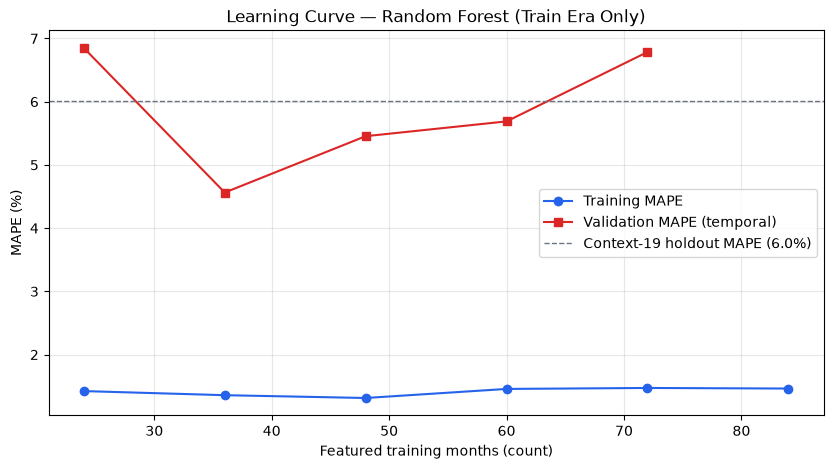

In [4]:
curve = learning_curve_points()
print(f"{'Train rows':>10} {'Train MAPE':>12} {'Val MAPE':>12}")
print("-" * 38)
for p in curve:
    val = f"{p.val_mape_pct:.2f}%" if p.val_mape_pct is not None else "—"
    print(f"{p.train_rows:>10} {p.train_mape_pct:>11.2f}% {val:>12}")

fig = plot_v9_learning_curve(curve)
display(Markdown(f"*{EVAL_CAPTIONS['v9']}*"))
plt.show()

## 4. Structural PSI vs D20 PSI

- **D20** (context-19): holdout actual vs holdout **predicted**
- **Structural** (context-20): train-era actual vs holdout **actual**

In [8]:
structural_psi = psi_structural_train_vs_holdout_actual()
_artifacts, _matrices = train_sales_model()
d20_psi = evaluate_forecast(
    _matrices.y_test, _artifacts.model.predict(_matrices.x_test)
).psi

print("PSI comparison (context-20 structural vs context-19 D20)\n")
print(f"  D20 PSI (holdout actual vs holdout predicted): {d20_psi:.4f}")
print(f"  Structural PSI (train-era actual vs holdout actual): {structural_psi:.4f}")
print("\nBoth elevated → era shift AND forecast mix mismatch on holdout.")

PSI comparison (context-20 structural vs context-19 D20)

  D20 PSI (holdout actual vs holdout predicted): 4.4767
  Structural PSI (train-era actual vs holdout actual): 8.3685

Both elevated → era shift AND forecast mix mismatch on holdout.


## 5. Context-19 distribution visuals (reference only)

No re-export — cite existing PNGs from context-19.

**V5 — binned actual vs predicted revenue mix (holdout)** — `docs/forecasting/outputs/v5_binned_distribution.png`

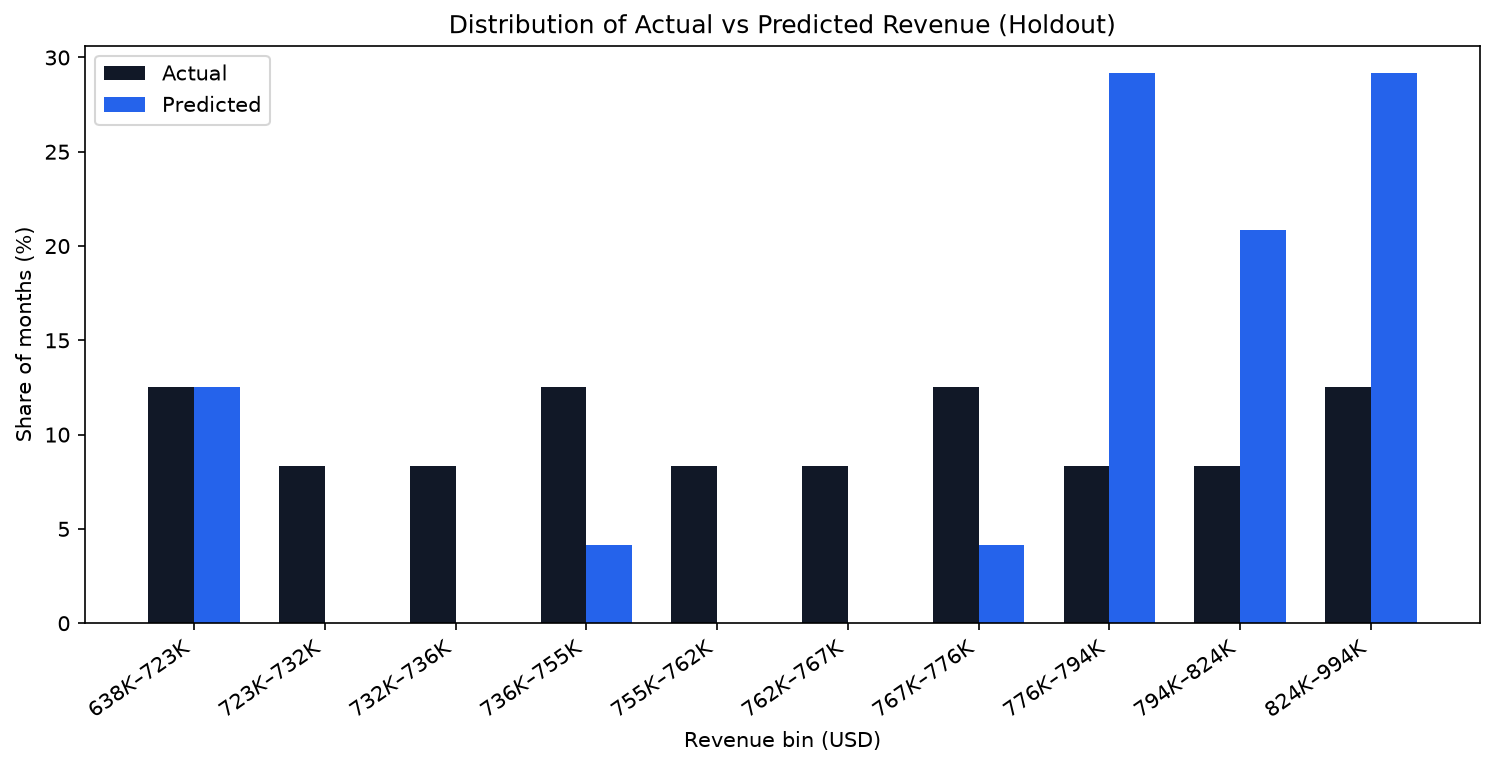

**V7 — seasonality by calendar month (holdout)** — `docs/forecasting/outputs/v7_seasonality_by_month.png`

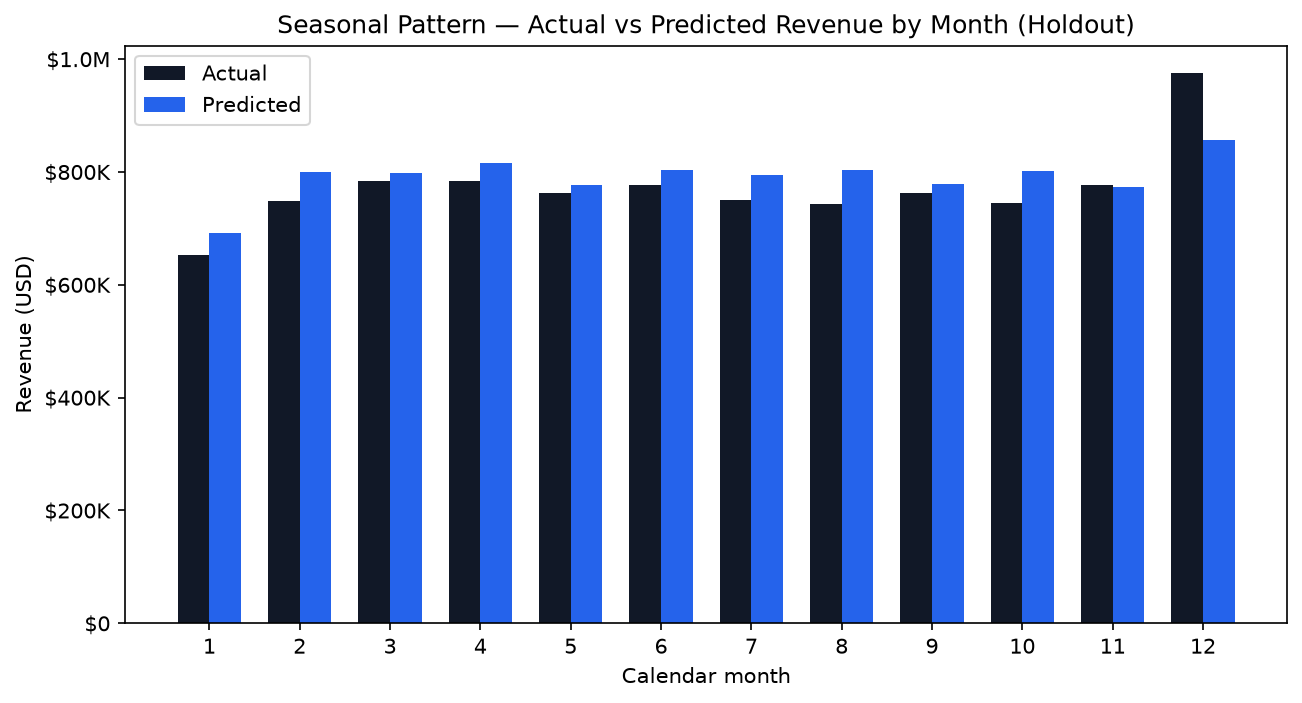

**V8 — residuals vs actual revenue (holdout)** — `docs/forecasting/outputs/v8_residuals.png`

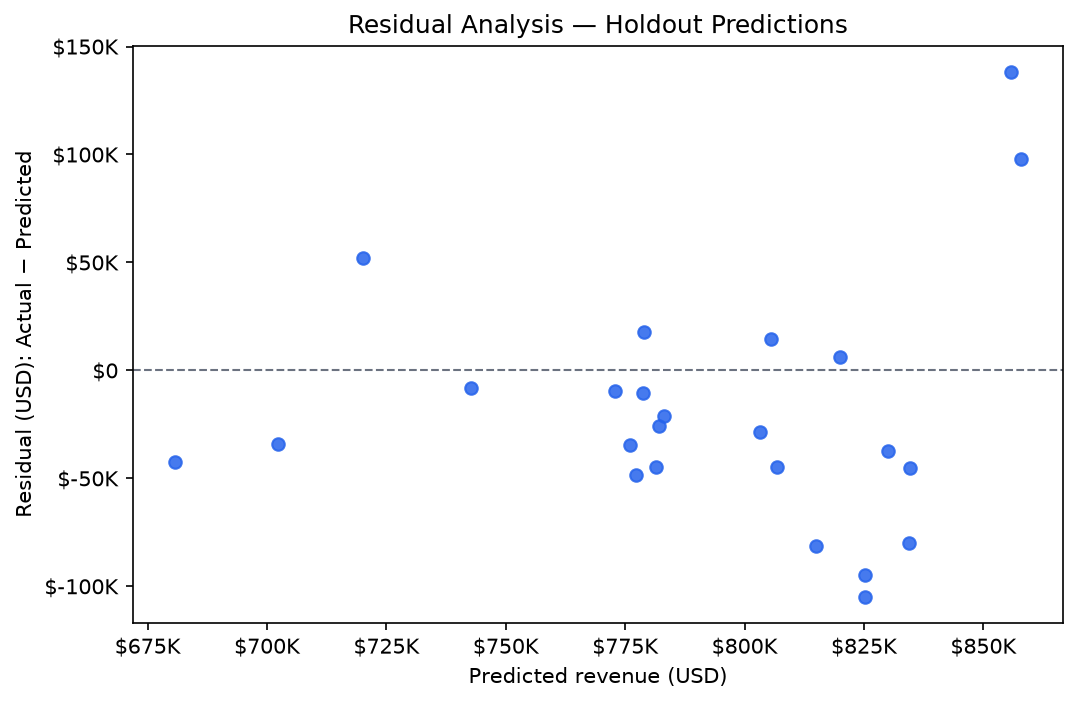

In [9]:
for name, caption in [
    ("v5_binned_distribution.png", "V5 — binned actual vs predicted revenue mix (holdout)"),
    ("v7_seasonality_by_month.png", "V7 — seasonality by calendar month (holdout)"),
    ("v8_residuals.png", "V8 — residuals vs actual revenue (holdout)"),
]:
    path = OUTPUT_DIR / name
    display(Markdown(f"**{caption}** — `{path.relative_to(_repo_root)}`"))
    display(Image(filename=str(path)))

## 6. V10 — CV fold chart

Export and display walk-forward validation MAPE by fold.

Saved evaluation visuals:
  v9: docs/forecasting/outputs/v9_learning_curve.png
  v10: docs/forecasting/outputs/v10_cv_fold_metrics.png


*Folds use pre-2024 data only; 2024–2025 is the single final holdout.*

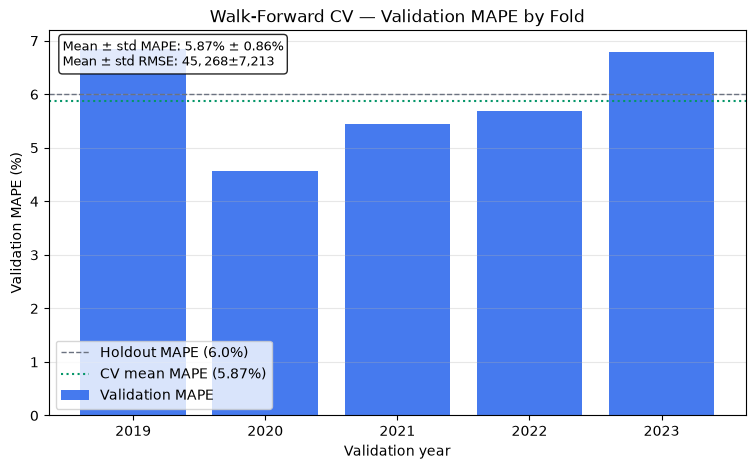

In [10]:
saved = save_evaluation_visuals(output_dir=OUTPUT_DIR)
print("Saved evaluation visuals:")
for key, path in saved.items():
    print(f"  {key}: {path.relative_to(_repo_root)}")

fig = plot_v10_cv_fold_metrics(cv_results, cv_summary)
display(Markdown(f"*{EVAL_CAPTIONS['v10']}*"))
plt.show()

## 7. Summary (for tech lead)

- **Holdout:** MAPE ~6%, Gini ~0.74 — ranking OK; PSI ~4.5, K2 ~16M — distribution/range fail
- **CV:** MAPE **5.87% ± 0.86%** — stable vs holdout; not an outlier
- **Learning curve:** **Overfitting** — train ~1.4% vs val ~5–7% MAPE gap
- **Structural PSI ~8.4** — holdout era differs from train history; D20 PSI also high
- **Verdict:** Do not promote on MAPE alone; see `docs/forecasting/EVALUATION-report.md` §9 for prose recommendations (no retrain in this ticket)